In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
df_index = pd.read_csv('economic_index.csv')

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
# as we have unnamed column we are gonna drop it..

In [13]:
# Dropping unnecessary columns
df_index.drop(columns = ['Unnamed: 0','year', 'month'],axis = 1,inplace = True)

KeyError: "['Unnamed: 0', 'year', 'month'] not found in axis"

In [15]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [20]:
#check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

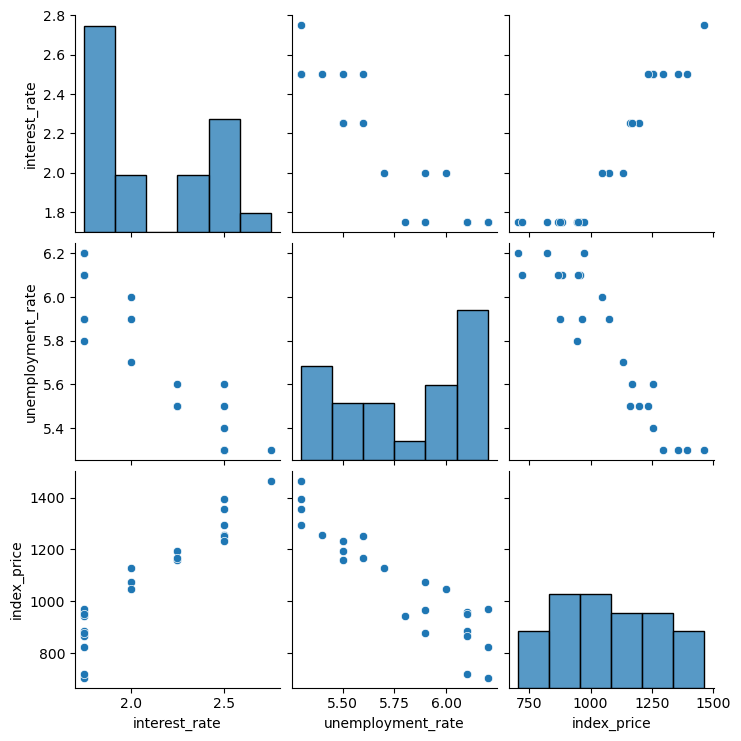

In [22]:
# Doing some visualization
import seaborn as sns
sns.pairplot(df_index)

In [24]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

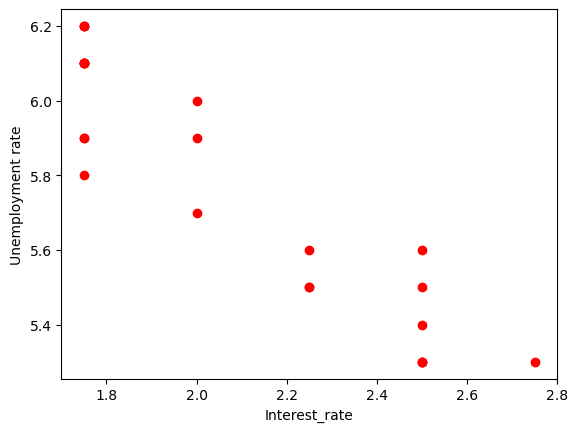

In [28]:
## Visualiziing more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'], color = 'r')
plt.xlabel('Interest_rate')
plt.ylabel('Unemployment rate')

In [33]:
##independent and depenedent features
X = df_index[['interest_rate', 'unemployment_rate']]
# X = df_index.iloc[[:,:-1]]
y = df_index[['index_price']]
# y = df_index.iloc[:,-1]

In [37]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [39]:
y

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [43]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

<AxesSubplot: xlabel='interest_rate', ylabel='index_price'>

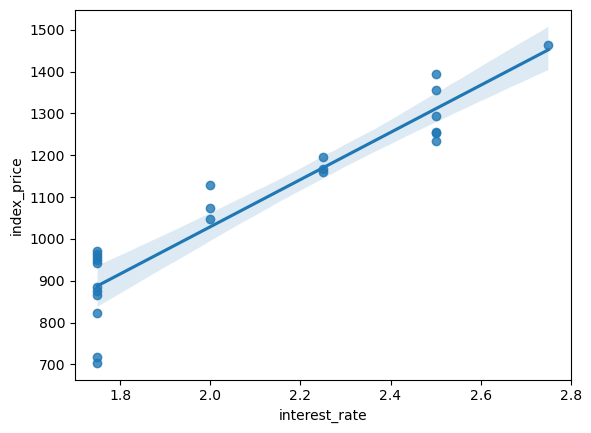

In [49]:
sns.regplot(data=df_index, x='interest_rate', y='index_price')

<AxesSubplot: xlabel='interest_rate', ylabel='unemployment_rate'>

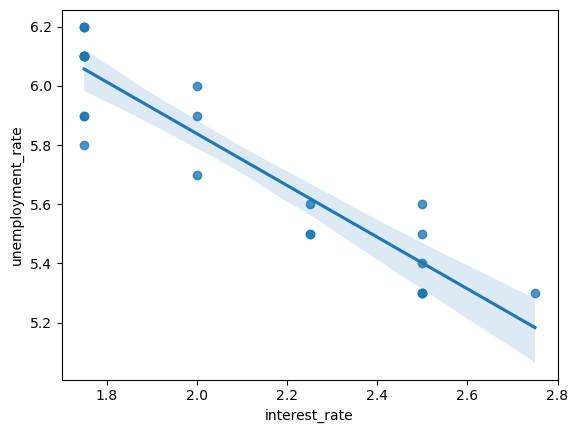

In [52]:
sns.regplot(data=df_index, x='interest_rate', y='unemployment_rate')


<AxesSubplot: xlabel='index_price', ylabel='unemployment_rate'>

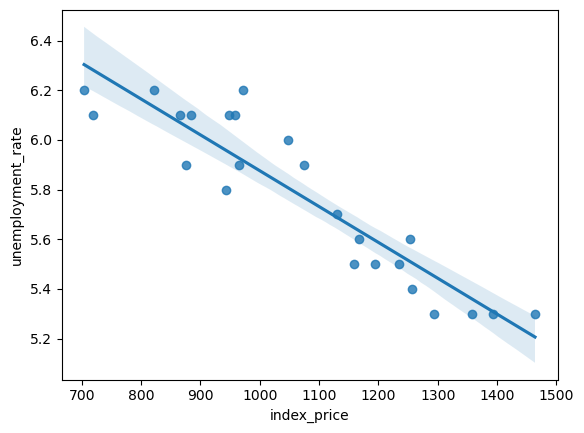

In [54]:
sns.regplot(data=df_index, x='index_price', y='unemployment_rate')

In [56]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [67]:
from sklearn.linear_model import LinearRegression

In [92]:
regression = LinearRegression(n_jobs = -1)


In [94]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [100]:
from sklearn.model_selection import cross_val_score

In [104]:
#cross validation
validation_score = cross_val_score(regression,X_train , y_train , scoring = 'neg_mean_squared_error',cv = 3)

In [103]:
np.mean(validation_score)

-5914.828180162389

In [105]:
## Prediction 
y_pred = regression.predict(X_test)

In [106]:
y_pred

array([[1204.22770398],
       [ 821.65051903],
       [1406.51300368],
       [ 857.70889608],
       [ 994.90992298],
       [1168.16932693]])

In [98]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [107]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712589
59.9357815232356
76.11677139574819


In [111]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print (1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.827897809145714
0.7131630152428566


### Assumptions

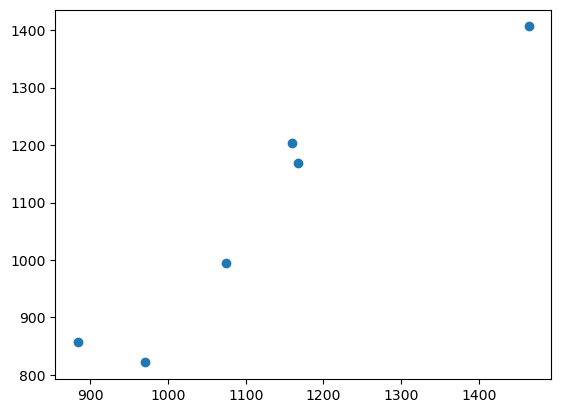

In [113]:
plt.scatter(y_test,y_pred)

In [115]:
residuals = y_test - y_pred
print(residuals)

    index_price
8    -45.227704
16   149.349481
0     57.486996
18    26.291104
11    80.090077
9     -1.169327


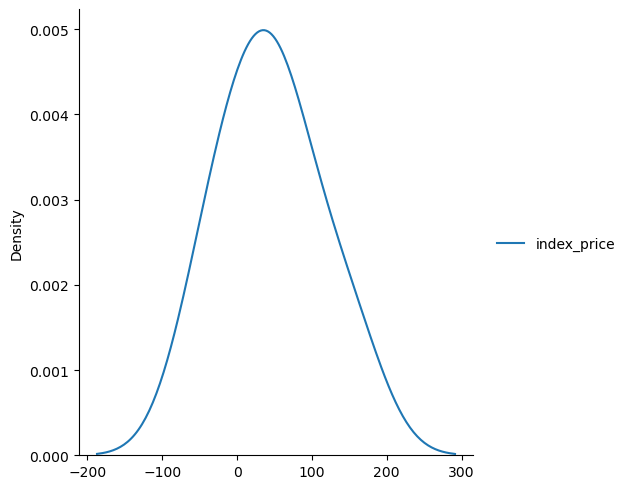

In [119]:
# Plot thsi residuals
sns.displot(residuals,kind = 'kde')

In [ ]:
# Scatter plot wth respect  to prediction and residuals
